In [17]:
#!pip install lightgbm


In [ ]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    mean_absolute_error,root_mean_squared_error,mean_squared_error,r2_score,make_scorer
)

In [19]:

df = pd.read_csv('Copia de data_merged.csv')



In [20]:

def aux(temp):
    if temp<=80:
        return 'lento'
    elif temp <=120:
        return 'moderado'
    return 'rapido'

df['duration_ms']= df['duration_ms']/60000
df['duration_ms_ar'] = df['duration_ms_ar']/60000
df['duration_ms_yr'] = df['duration_ms_yr']/60000

df['energy_ratio_yr'] = df['energy_yr']*df['acousticness_yr']
df['electro_focus_yr'] = (1-df['acousticness_yr'])*df['energy_yr']*df['instrumentalness_yr']
df['vocal_energy_yr'] = (1-df['instrumentalness_yr'])*df['energy_yr']

df['energy_ratio_'] = df['energy']*df['acousticness']
df['electro_focus'] = (1-df['acousticness'])*df['energy']*df['instrumentalness']
df['vocal_energy'] = (1-df['instrumentalness'])*df['energy']

df['energy_ratio_ar'] = df['energy_ar']*df['acousticness_ar']
df['electro_focus_ar'] = (1-df['acousticness_ar'])*df['energy_ar']*df['instrumentalness_ar']
df['vocal_energy_ar'] = (1-df['instrumentalness_ar'])*df['energy_ar']


df['temp_range'] = df['tempo_yr'].apply(aux)
df = pd.get_dummies(df,columns=['temp_range'],prefix='temp')
df[['temp_moderado','temp_rapido']] = df[['temp_moderado','temp_rapido']].astype(int)

In [21]:
X = df.drop('popularity',axis=1)
y=df['popularity']

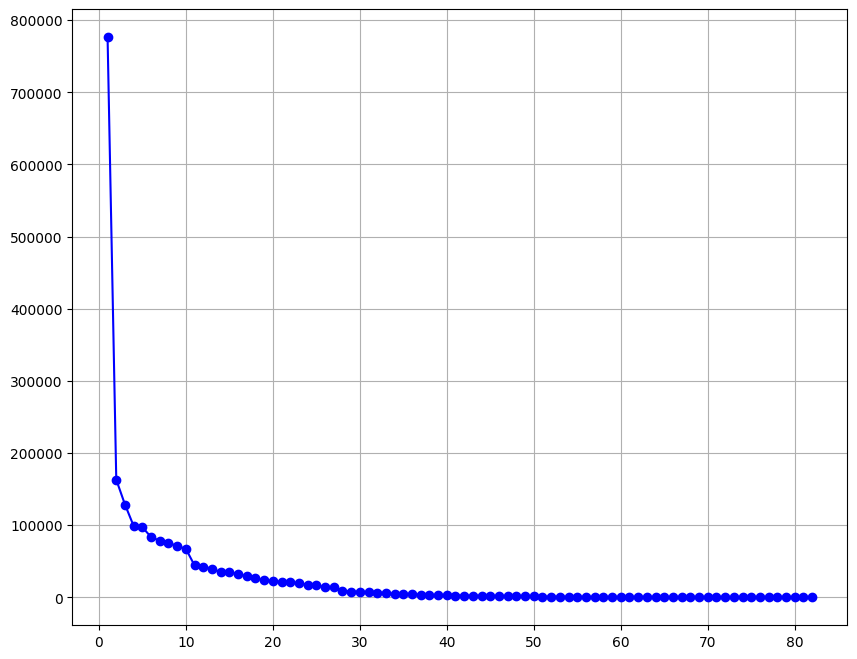

In [22]:

selector = SelectKBest(score_func=f_regression,k='all')
X_new = selector.fit_transform(X,y)
total_score = selector.scores_
sorted_scoress = np.sort(total_score)[::-1]
plt.figure(figsize=(10,8))
plt.grid(visible=True)
plt.plot(range(1,X.shape[1]+1),sorted_scoress,'bo-')


In [23]:

selector = SelectKBest(score_func=f_regression,k=20)
X_new = selector.fit_transform(X,y)
select = selector.get_feature_names_out()
select


array(['acousticness', 'energy', 'loudness', 'year', 'acousticness_ar',
       'energy_ar', 'instrumentalness_ar', 'loudness_ar', 'popularity_ar',
       'acousticness_yr', 'duration_ms_yr', 'energy_yr',
       'instrumentalness_yr', 'loudness_yr', 'speechiness_yr', 'tempo_yr',
       'popularity_yr', 'vocal_energy_yr', 'vocal_energy',
       'vocal_energy_ar'], dtype=object)

In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y)

In [25]:
y_train_log = np.log1p(y_train)
model = lgb.LGBMRegressor(
    metric='mae',
    verbosity=-1,
    features_fraction =0.7
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:

params={
    'n_estimators':[100,300,500,600],
    'learnig_rate':[0.01,0.05,0.1],
    'max_depth':[-1,5,10,15],
    'num_leaves':[63,31,20,127],
    'min_split_gain':[0,0.1,0.2]

}
mae_scorer = make_scorer(mean_absolute_error,greater_is_better=False)
grid = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    scoring=mae_scorer,
    cv=3,
    n_iter=300,
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train_scaled,y_train_log)
best_model = grid.best_estimator_
print(grid.best_params_)
    

Fitting 3 folds for each of 300 candidates, totalling 900 fits
[CV] END learnig_rate=0.1, max_depth=-1, min_split_gain=0.2, n_estimators=100, num_leaves=63; total time=  12.1s
[CV] END learnig_rate=0.1, max_depth=-1, min_split_gain=0.2, n_estimators=100, num_leaves=63; total time=  12.2s
[CV] END learnig_rate=0.1, max_depth=-1, min_split_gain=0.2, n_estimators=100, num_leaves=63; total time=  12.5s
[CV] END learnig_rate=0.1, max_depth=-1, min_split_gain=0.1, n_estimators=100, num_leaves=20; total time=   5.4s
[CV] END learnig_rate=0.1, max_depth=-1, min_split_gain=0.1, n_estimators=100, num_leaves=20; total time=   5.5s
[CV] END learnig_rate=0.1, max_depth=10, min_split_gain=0.2, n_estimators=500, num_leaves=31; total time=  18.4s
[CV] END learnig_rate=0.1, max_depth=10, min_split_gain=0.2, n_estimators=500, num_leaves=31; total time=  19.0s
[CV] END learnig_rate=0.1, max_depth=-1, min_split_gain=0.1, n_estimators=100, num_leaves=20; total time=   6.0s
[CV] END learnig_rate=0.05, max_d

In [27]:
y_predict_log = best_model.predict(X_test_scaled)
y_pred = np.round(np.expm1(y_predict_log)).clip(0,100).astype(int)

In [28]:
mae = mean_absolute_error(y_test,y_pred)
mae

4.959194574759627

In [29]:
r2 = r2_score(y_test,y_pred)
r2


0.860012633305947

In [30]:
rmse = root_mean_squared_error(y_test,y_pred)
rmse

8.185986888951835

In [31]:
mse = mean_squared_error(y_test,y_pred)
mse

67.01038134609132

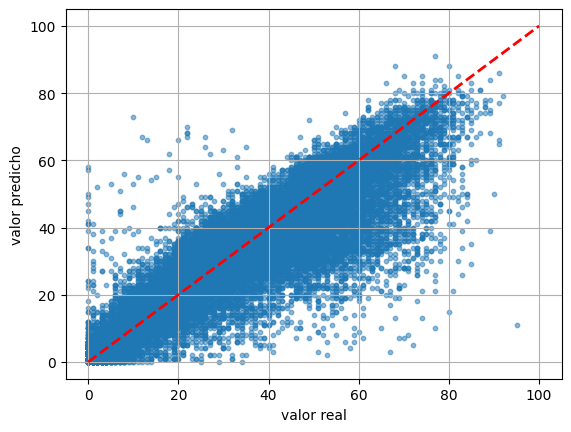

In [32]:
plt.scatter(y_test,y_pred,alpha=0.5,s=10)
plt.plot([0,100],[0,100],'r--',linewidth=2)
plt.xlabel('valor real')
plt.ylabel("valor predicho")
plt.grid()
plt.show()

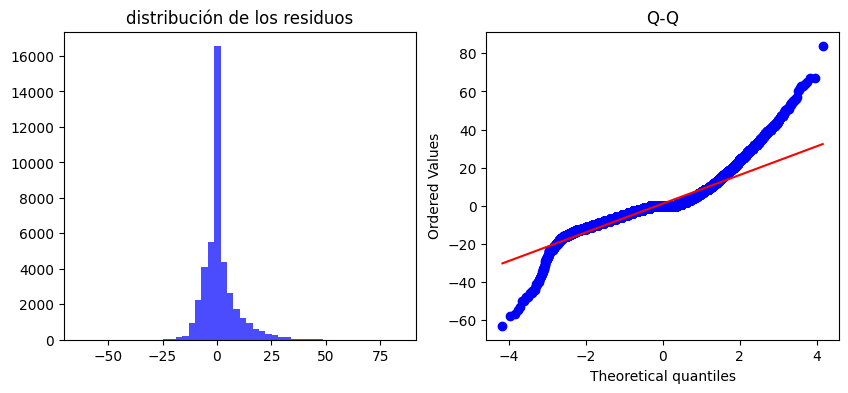

In [33]:
residual = y_test - y_pred

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(residual,bins=50,alpha=0.7,color='blue')
plt.title("distribución de los residuos")

plt.subplot(1,2,2)
from scipy import stats
stats.probplot(residual,plot=plt)
plt.title("Q-Q")
plt.show()

stat_lf,p_value = stats.kstest(residual,'norm',args=(np.mean(residual),np.std(residual)))

In [34]:
print(f"p_valor: {p_value:.1f}")

p_valor: 0.0


In [35]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(algorithm='auto')
params ={
    'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance'],
    'metric':['eucliden','manhattan'],
}
gridk = GridSearchCV(
    knn,param_grid=params,cv=3,verbose=2,n_jobs=-1
) 
gridk.fit(X_train_scaled,y_train_log)
model_knn = gridk.best_estimator_
print(gridk.best_params_)


Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END ....metric=eucliden, n_neighbors=3, weights=uniform; total time=   0.2s
[CV] END ....metric=eucliden, n_neighbors=3, weights=uniform; total time=   0.2s
[CV] END ....metric=eucliden, n_neighbors=3, weights=uniform; total time=   0.2s
[CV] END ...metric=eucliden, n_neighbors=3, weights=distance; total time=   0.2s
[CV] END ...metric=eucliden, n_neighbors=3, weights=distance; total time=   0.2s
[CV] END ...metric=eucliden, n_neighbors=3, weights=distance; total time=   0.2s
[CV] END ....metric=eucliden, n_neighbors=5, weights=uniform; total time=   0.2s
[CV] END ....metric=eucliden, n_neighbors=5, weights=uniform; total time=   0.2s
[CV] END ....metric=eucliden, n_neighbors=5, weights=uniform; total time=   0.2s
[CV] END ...metric=eucliden, n_neighbors=5, weights=distance; total time=   0.2s
[CV] END ...metric=eucliden, n_neighbors=5, weights=distance; total time=   0.2s
[CV] END ...metric=eucliden, n_neighbors=5, weig

In [36]:
y_predict_log = model_knn.predict(X_test_scaled)
y_pred = np.round(np.expm1(y_predict_log)).clip(0,100).astype(int)

In [37]:
mae = mean_absolute_error(y_test,y_pred)
mae

6.24448418412374

In [38]:
r2 = r2_score(y_test,y_pred)
r2


0.7791363460168477

In [39]:
rmse = root_mean_squared_error(y_test,y_pred)
rmse

10.282263971995652

In [40]:
mse = mean_squared_error(y_test,y_pred)
mse

105.72495238979981

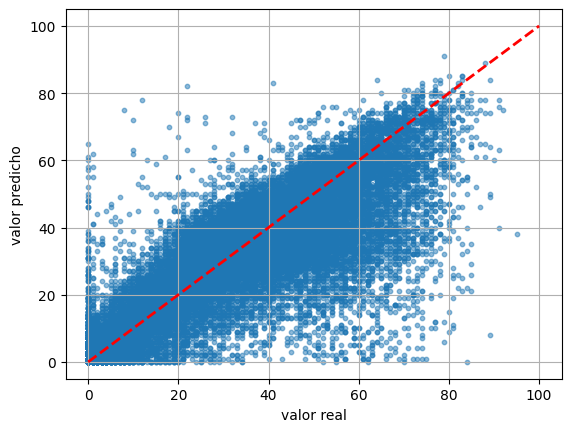

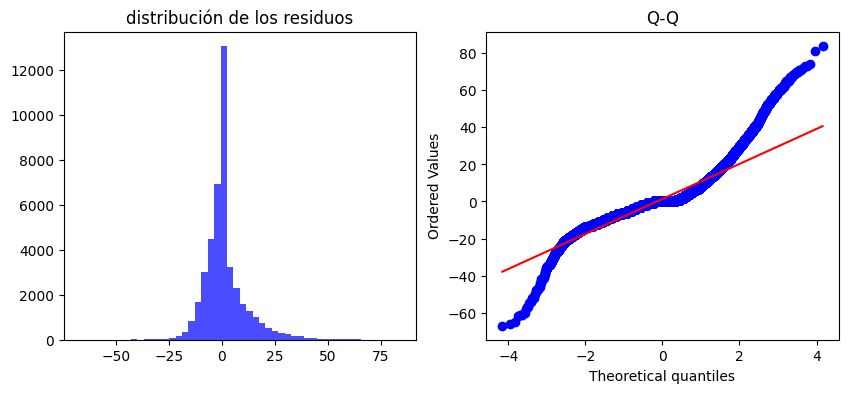

In [41]:
plt.scatter(y_test,y_pred,alpha=0.5,s=10)
plt.plot([0,100],[0,100],'r--',linewidth=2)
plt.xlabel('valor real')
plt.ylabel("valor predicho")
plt.grid()
plt.show()
residual = y_test - y_pred

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(residual,bins=50,alpha=0.7,color='blue')
plt.title("distribución de los residuos")

plt.subplot(1,2,2)
from scipy import stats
stats.probplot(residual,plot=plt)
plt.title("Q-Q")
plt.show()

stat_lf,p_value = stats.kstest(residual,'norm',args=(np.mean(residual),np.std(residual)))

In [42]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso

linear = LinearRegression()


linear.fit(X_train_scaled,y_train_log)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
y_predict_log = linear.predict(X_test_scaled)
y_pred = np.round(np.expm1(y_predict_log)).clip(0,100).astype(int)

In [44]:
r2 = r2_score(y_test,y_pred)
r2


0.6385259254974355

In [45]:
mae = mean_absolute_error(y_test,y_pred)
mae

8.534023874773562

In [46]:
rmse = root_mean_squared_error(y_test,y_pred)
rmse

13.154222995278111

In [47]:
mse = mean_squared_error(y_test,y_pred)
mse

173.03358260950347

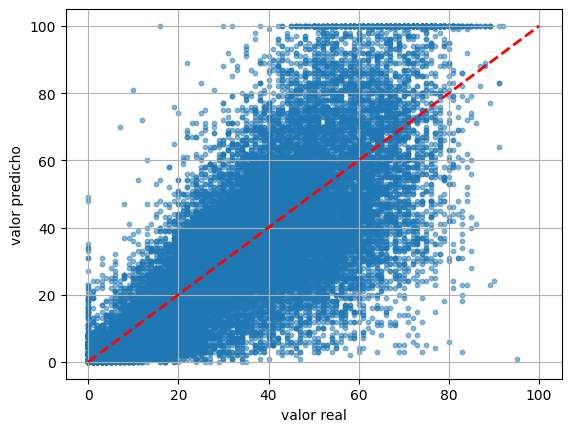

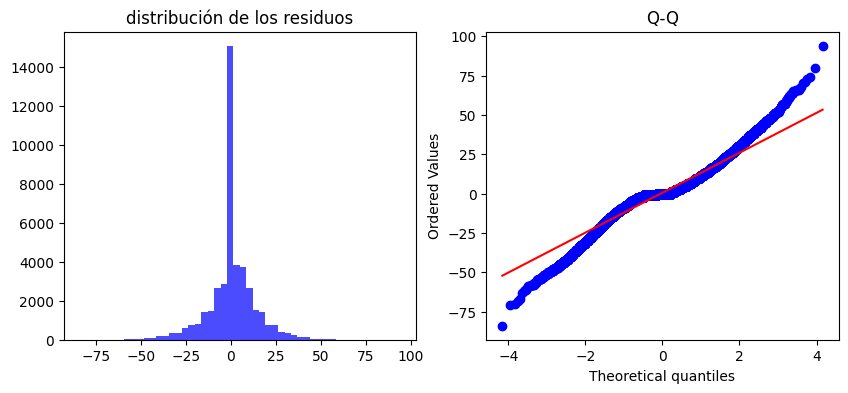

In [48]:
plt.scatter(y_test,y_pred,alpha=0.5,s=10)
plt.plot([0,100],[0,100],'r--',linewidth=2)
plt.xlabel('valor real')
plt.ylabel("valor predicho")
plt.grid()
plt.show()
residual = y_test - y_pred

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(residual,bins=50,alpha=0.7,color='blue')
plt.title("distribución de los residuos")

plt.subplot(1,2,2)
from scipy import stats
stats.probplot(residual,plot=plt)
plt.title("Q-Q")
plt.show()

stat_lf,p_value = stats.kstest(residual,'norm',args=(np.mean(residual),np.std(residual)))

In [49]:
p_value

np.float64(0.0)